### Compare bulk RNA-seq treating it as "ground truth" against DESeq2 with pseudobulked "batch as covariate" approach and meta-analysis approach 

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
def classify_DEGs(DEG_df, pval_col, FC_col, pval_thresh=0.05, log2fc_thresh=0.5):
    DEG_df = DEG_df.copy()
    
    conditions = [
        (DEG_df[pval_col] < pval_thresh) & (DEG_df[FC_col] > log2fc_thresh),
        (DEG_df[pval_col] < pval_thresh) & (DEG_df[FC_col] < -log2fc_thresh)
    ]
    choices = ["up", "down"]

    DEG_df["direction"] = np.select(conditions, choices, default="non-sig")
    return DEG_df

In [4]:
def plot_confusion(y_true, y_pred, labels=["up", "down", "non-sig"], title="Confusion matrix", vmax=None):

    '''Produce confusion plot'''
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_log = np.log1p(cm)  # log scale with log(1 + x)
    
    sns.heatmap(cm_log, annot=cm, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", vmax=vmax)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    return plt

In [5]:
bulk_aging_df = pd.read_csv("01_GTEx_subsampled_bulk_age_group_old_vs_young.csv", index_col = 0)
bulk_aging_df = classify_DEGs(bulk_aging_df, pval_col = "padj", FC_col = "log2FoldChange",  
                            pval_thresh=0.05, log2fc_thresh=0.5)

aging_cov_df = pd.read_csv("batch_as_covariate_pydeseq2_results/pseudobulked_age_group_old_vs_young_results.csv", index_col = 0)
aging_cov_df = classify_DEGs(aging_cov_df, pval_col = "padj", FC_col = "log2FoldChange")

aging_meta_df = pd.read_csv("per_study_age_results_dir/meta_analysis_aging.csv", index_col = 0)
aging_meta_df.index = aging_meta_df.gene_id
aging_meta_df = classify_DEGs(aging_meta_df, pval_col = "meta_padj", FC_col = "meta_log2FC")

intersecting_genes = list(set(bulk_aging_df.index) & set(aging_cov_df.index) & set(aging_meta_df.index))

bulk_aging_df = bulk_aging_df.loc[intersecting_genes]
aging_cov_df = aging_cov_df.loc[intersecting_genes]
aging_meta_df = aging_meta_df.loc[intersecting_genes]

In [6]:
combined_df = pd.DataFrame({
    "bulk": bulk_aging_df["direction"],
    "covariate": aging_cov_df["direction"],
    "meta": aging_meta_df["direction"]
})

In [7]:
def build_cm(truth, pred, labels=["up", "down", "non-sig"]):
    '''Produce a 3x3 contingency matrix'''

    cm = pd.DataFrame(
        confusion_matrix(truth, pred, labels=labels),
        index=[f"true_{l}" for l in labels],
        columns=[f"pred_{l}" for l in labels]
    )
    
    return cm


def collapse_to_binary(cm_full):
    '''
    Collapse a 3x3 contingency matrix into 2x2 binary:
    Positive = up or down
    Negative = non-sig

    Calculate the sensitivity and specificity
    '''
    
    # TP = true positive = correctly predicted up/down
    TP = cm_full.loc[["true_up","true_down"], ["pred_up","pred_down"]].values.sum()
    
    # FN = false negative = truth positive but predicted non-sig
    FN = cm_full.loc[["true_up","true_down"], ["pred_non-sig"]].values.sum()
    
    # FP = false positive = truth non-sig but predicted up/down
    FP = cm_full.loc[["true_non-sig"], ["pred_up","pred_down"]].values.sum()
    
    # TN = true negative = truth non-sig predicted non-sig
    TN = cm_full.loc[["true_non-sig"], ["pred_non-sig"]].values.sum()
    
    # sensitivity and specificity
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    
    cm_binary = pd.DataFrame([[TP, FN],[FP, TN]],
                             index=["true_pos","true_neg"],
                             columns=["pred_pos","pred_neg"])
    
    return cm_binary, sensitivity, specificity

In [8]:
cm_cov = build_cm(combined_df['bulk'], combined_df['covariate'])
binary_cm_cov, cov_sens, cov_spec = collapse_to_binary(cm_cov)

print(cov_sens)
print(cov_spec)

0.018196856906534328
0.9942972912133263


In [9]:
cm_meta = build_cm(combined_df['bulk'], combined_df['meta'])
binary_cm_meta, cov_meta, cov_spec = collapse_to_binary(cm_meta)

print(cov_meta)
print(cov_spec)

0.005789909015715467
0.9977489307421025


In [10]:
metrics_df = pd.DataFrame({
    "Comparison": ["bulk vs cov", "bulk vs meta"],
    "Sensitivity": [cov_sens, cov_meta],
    "Specificity": [cov_spec, cov_spec]  # make sure spec values are correct for each
})

metrics_melted = metrics_df.melt(id_vars="Comparison", var_name="Metric", value_name="Value")

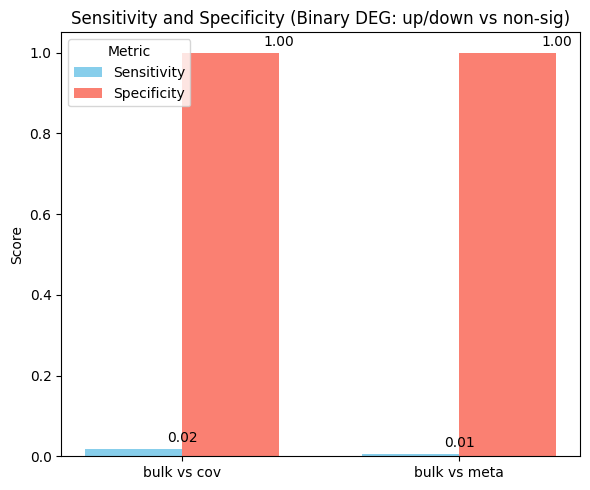

In [11]:
plt.figure(figsize=(6,5))
colors = {"Sensitivity": "skyblue", "Specificity": "salmon"}

comparisons = metrics_melted["Comparison"].unique()
metrics = metrics_melted["Metric"].unique()
width = 0.35  # width of bars
x = range(len(comparisons))

# plot bars side by side
for i, metric in enumerate(metrics):
    vals = metrics_melted[metrics_melted["Metric"] == metric]["Value"].values
    plt.bar([pos + i*width for pos in x], vals, width=width, color=colors[metric], label=metric)

plt.xticks([pos + width/2 for pos in x], comparisons)

for i, metric in enumerate(metrics):
    vals = metrics_melted[metrics_melted["Metric"] == metric]["Value"].values
    for xi, val in zip([pos + i*width for pos in x], vals):
        plt.text(xi + width/2, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Sensitivity and Specificity (Binary DEG: up/down vs non-sig)")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("04B_aging_sensitivity_and_specificity.pdf")
plt.show()

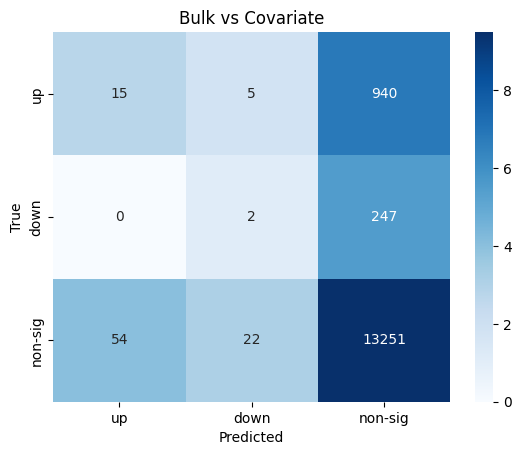

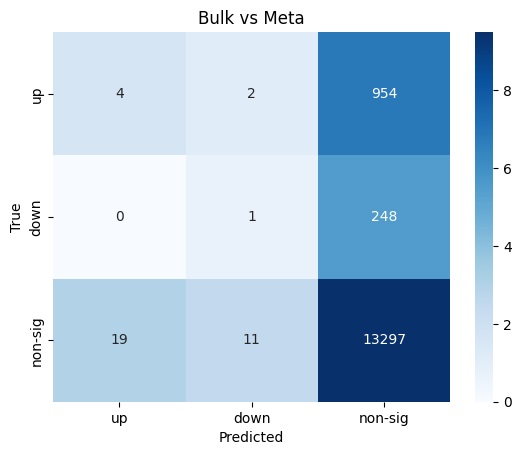

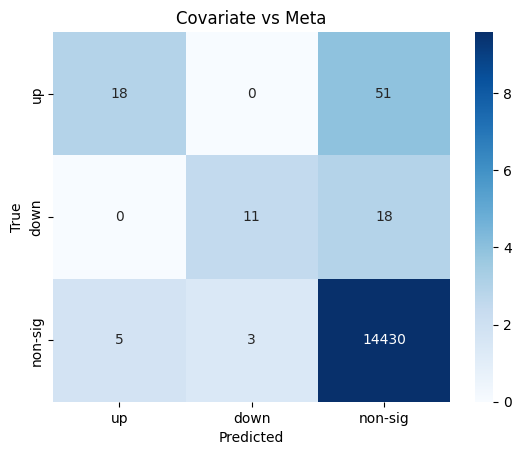

In [12]:
plot_confusion(combined_df["bulk"], combined_df["covariate"], title="Bulk vs Covariate")
plt.savefig("04B_aging_bulk_vs_covariate.pdf")
plt.show()

plot_confusion(combined_df["bulk"], combined_df["meta"], title="Bulk vs Meta")
plt.savefig("04B_aging_bulk_vs_meta.pdf")
plt.show()

plot_confusion(combined_df["covariate"], combined_df["meta"], title="Covariate vs Meta")
plt.savefig("04B_aging_cov_vs_meta.pdf")
plt.show()